In [1]:
import os
import sys
sys.path.append(os.path.abspath('../../'))
from utlis.Ca_tools.roi_spike_vis_utlis import *

# Example Workflow
# Load data

minian_path = "/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20240919-V1-R1/customEntValHere/2024_12_18/11_33_01/My_V4_Miniscope/"
# '/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20241002-pmc-r2/customEntValHere/2024_10_25/15_50_39/My_V4_Miniscope/' # minian_dataset.nc'/data/big_rim/mir_data/Oct3V1mini/Oct3V1mini_sorted/20241002-pmc-r2/customEntValHere/2024_10_25/17_09_14/My_V4_Miniscope' 
mini_timestamps = os.path.join(minian_path, 'timeStamps.csv')
data, ts = load_minian_data(minian_path, mini_timestamps)

dF_F = calculate_dff(data)

# # Plot all neurons' raw signals
# plot_all_neurons(data['C'].values, ts)

# # Plot all neurons' ΔF/F signals
# plot_all_dff(dF_F, ts)

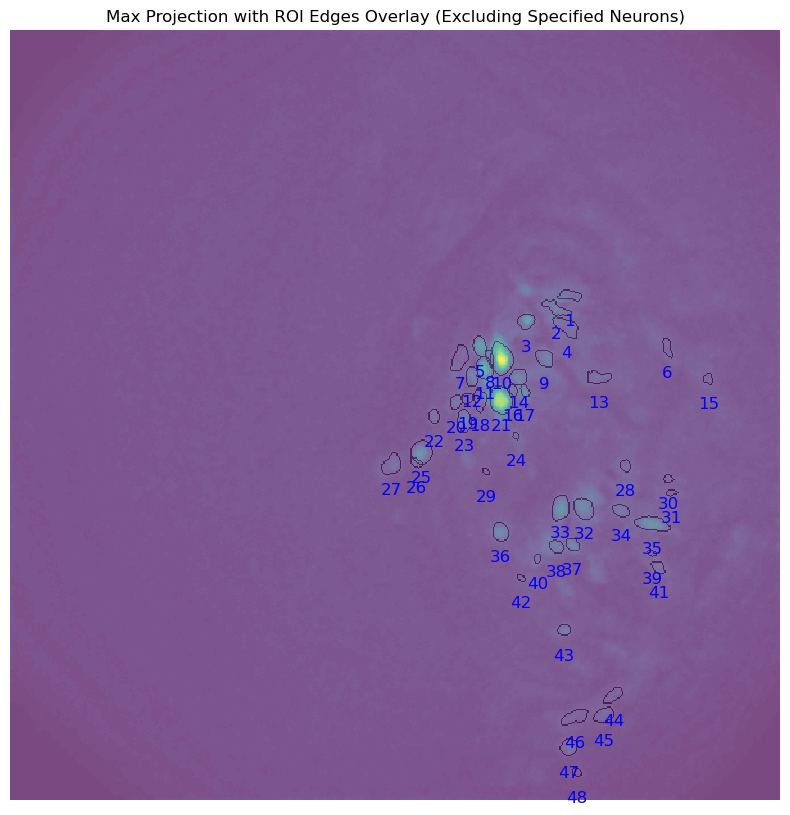

In [3]:
# from utlis.Ca_tools.roi_spike_vis_utlis import overlay_roi_edges_exclude
# Provide manually selected neurons
df = pd.DataFrame({f'calcium_roi{i}': dF_F[i] for i in range(dF_F.shape[0])}, index=ts)
# selected_neurons = [54, 57, 66, 38, 42, 37, 51]  # Replace with your manual selection
#extreme exclude: [36, 34, 33, 27, 28, 30, 31, 29, 26, 54, 56, 72, 75, 58, 59, 62, 69, 68, 70, 76, 71, 73, 55, 91, 88, 90, 60, 67,54, 32,  41, 13, 10, 8, 49, 52, 81, 86, 35, 37, 38, 87, 84, 82, 93, 92, 79, 77, 23, 24, 21, 18, 15, 11, 16, 78, 74, 54, 57, 83, 89, 0,1,2,3,4,5,6,7,9,12,14,17,20,22,25,94,95,80,85]
# excluded_neurons = [ 27, 28, 30, 31, 29, 26, 54, 56, 72, 75, 58, 59, 62, 69, 68, 70, 76, 71, 73, 55, 91, 88, 90, 60, 67,32,  41,  8, 49, 81, 86, 87, 84, 82, 93, 92, 79, 77, 23, 24, 21, 18, 15, 11, 16, 78, 74, 54, 57, 83, 89, 0,1,2,3,4,5,6,7,9,12,14,17,20,22,25,94,95,80,85]
#[3,8,46,75,78,55,11,56, 18, 84, 10, 77, 76, 74, 7, 2, 9, 17, 10, 12, 14, 15, 16, 18, 19, 13, 17, 0, 20, 60, 63, 70, 79, ]  # List of numbers you want to exclude
excluded_neurons = [0]
# Plot signals and ΔF/F
# plot_calcium_signals(df, selected_neurons)
# plot_dff(dF_F, ts, selected_neurons)

# Overlay ROI edges
max_proj = data['max_proj'].values
# manual_selection = [50, 57, 40, 62]  # Replace with your manual selection
# overlay_roi_edges(data, max_proj, selected_neurons)
overlay_roi_edges_exclude(data, max_proj, excluded_neurons)

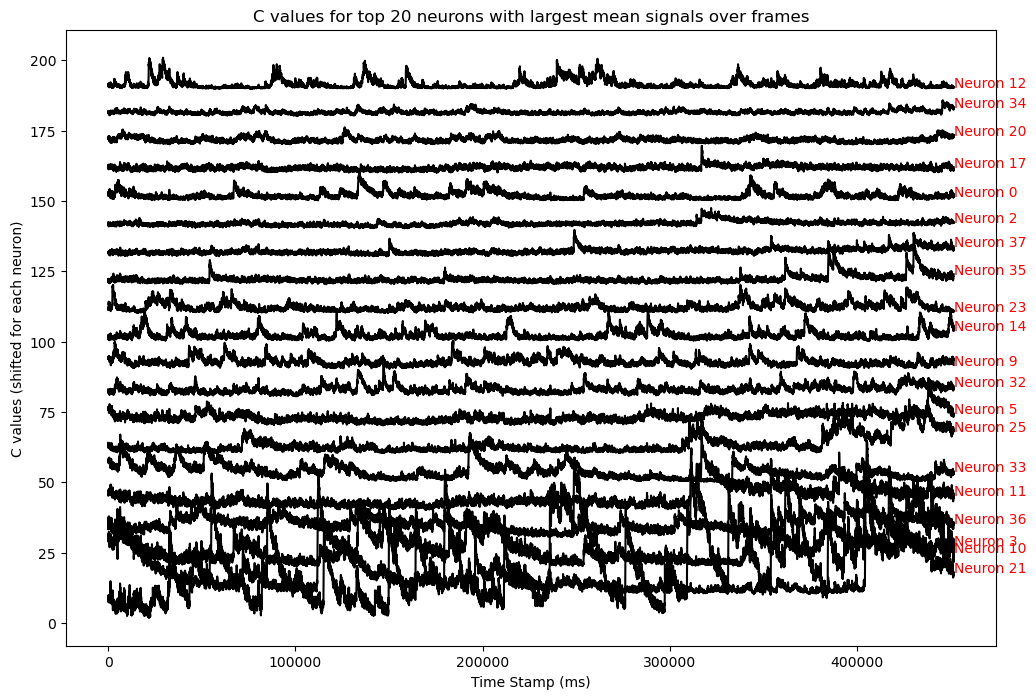

Top 20 neuron indices by mean value:
[10 21  3 36 11 33 25  5 32  9 14 23 35 37  2  0 17 20 34 12]


In [4]:
# this method have a better shifting pattern, thus looks different.
# Extract the 'C' variable
C = data['C'].values

# Get the number of neurons and frames
num_neuron, num_frame = C.shape

# Calculate the mean across frames for each neuron
mean_C = np.mean(C, axis=1)

# Get the indices that would sort the neurons by their mean values in descending order
sorted_indices = np.argsort(mean_C)[::-1]

# Select the top 10-20 neurons (here we choose 20)
top_neurons = 20
selected_indices = sorted_indices[:top_neurons]

# # Plot the C values for each selected neuron, without the neuron#
# plt.figure(figsize=(12, 8))
# for i, neuron_index in enumerate(selected_indices):
#     plt.plot(C[neuron_index] + i * 20, color='black')  # Set the color to black

# plt.xlabel('Frame')
# plt.ylabel('C values (shifted for each neuron)')
# plt.title('C values for top 20 neurons with largest mean signals over frames')
# plt.show()


# Plot the C values for each selected neuron and print their indices for manual selection
# plt.figure(figsize=(12, 8))
# for i, neuron_index in enumerate(selected_indices):
#     plt.plot(C[neuron_index] + i * 20, color='black', label=f'Neuron {neuron_index}')  # Set the color to black
#     plt.text(num_frame - 1, C[neuron_index][-1] + i * 20, f'Neuron {neuron_index}', color='red')  # Annotate each neuron index


# Plot the C values for each selected neuron and print their indices for manual selection, with timestamps
plt.figure(figsize=(12, 8))
for i, neuron_index in enumerate(selected_indices):
    plt.plot(ts, C[neuron_index] + i * 10, color='black', label=f'Neuron {neuron_index}')  # Set the color to black
    plt.text(ts[-1], C[neuron_index][-1] + i * 10, f'Neuron {neuron_index}', color='red')  # Annotate each neuron index

plt.xlabel('Time Stamp (ms)')
plt.ylabel('C values (shifted for each neuron)')
plt.title('C values for top 20 neurons with largest mean signals over frames')
plt.show()

# Print the selected neuron indices for reference
print("Top 20 neuron indices by mean value:")
print(selected_indices)




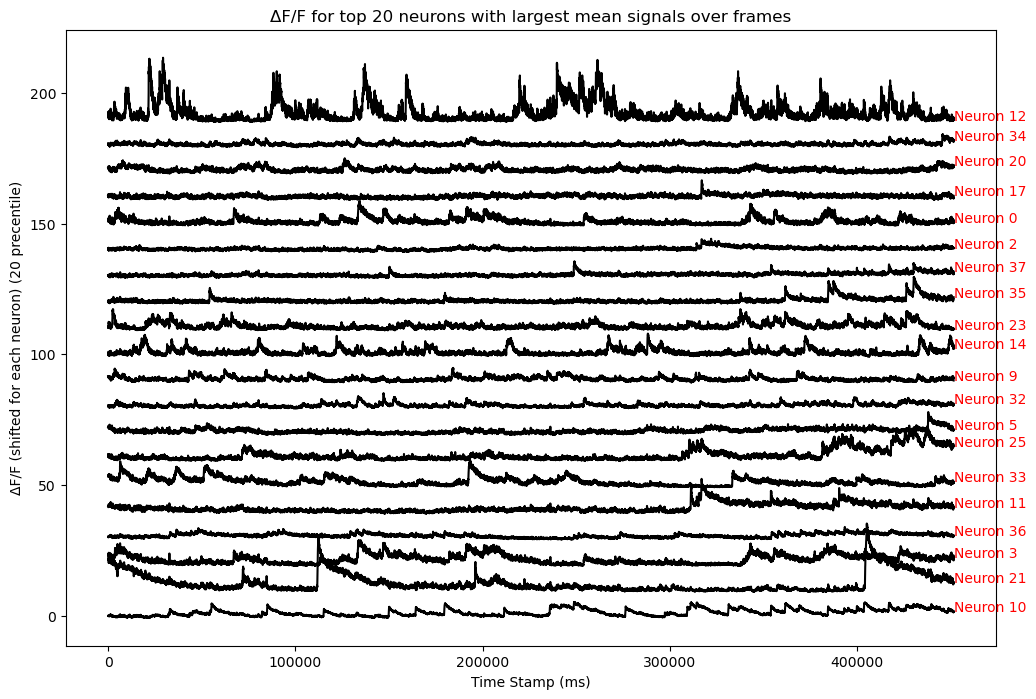

Top 20 neuron indices by mean ΔF/F (20 precentile) value:
[10 21  3 36 11 33 25  5 32  9 14 23 35 37  2  0 17 20 34 12]


In [5]:
# Calculate F0 (the baseline) for each neuron as the 10th percentile of fluorescence
F0 = np.percentile(C, 20, axis=1, keepdims=True)

# Calculate ΔF/F for each neuron
dF_F = (C - F0) / F0

# Plot the ΔF/F values for each selected neuron and print their indices for manual selection, with timestamps
plt.figure(figsize=(12, 8))
for i, neuron_index in enumerate(selected_indices):
    plt.plot(ts, dF_F[neuron_index] + i * 10, color='black', label=f'Neuron {neuron_index}')  # Set the color to black
    plt.text(ts[-1], dF_F[neuron_index][-1] + i * 10, f'Neuron {neuron_index}', color='red')  # Annotate each neuron index

plt.xlabel('Time Stamp (ms)')
plt.ylabel('ΔF/F (shifted for each neuron) (20 precentile)')
plt.title('ΔF/F for top 20 neurons with largest mean signals over frames')
plt.show()

# Print the selected neuron indices for reference
print("Top 20 neuron indices by mean ΔF/F (20 precentile) value:")
print(selected_indices)


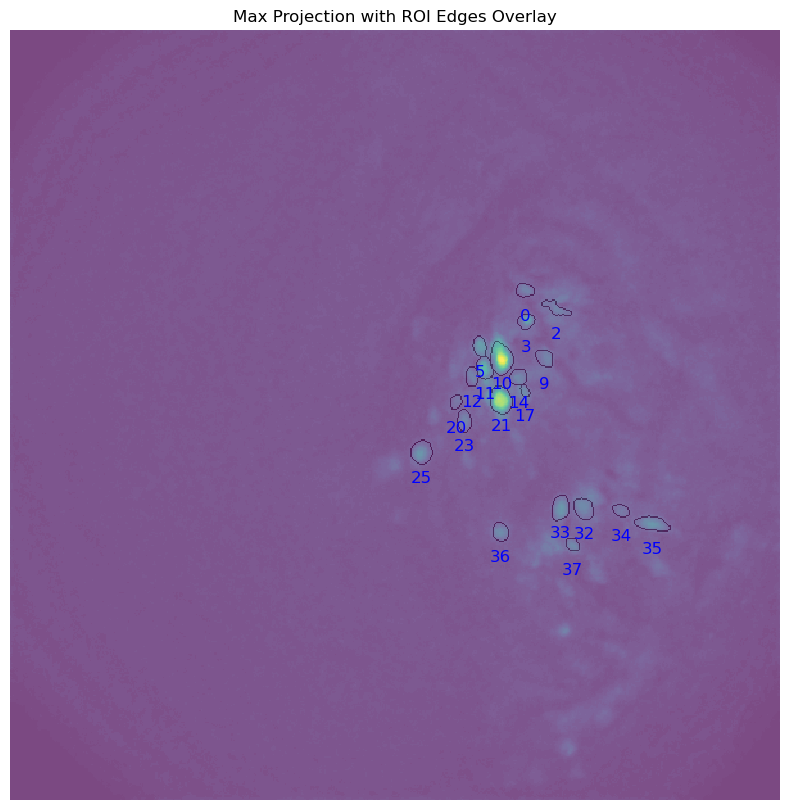

In [8]:
# from utlis.Ca_tools.roi_spike_vis_utlis import overlay_roi_edges_exclude
# Provide manually selected neurons
df = pd.DataFrame({f'calcium_roi{i}': dF_F[i] for i in range(dF_F.shape[0])}, index=ts)
selected_neurons = [10, 21,  3, 36, 11, 33, 25,  5, 32,  9, 14, 23, 35, 37,  2,  0, 17, 20, 34, 12]
# [1,44,35,6] #[54, 57, 66, 38, 42, 37, 51]  # Replace with your manual selection
# excluded_neurons = [3,8,46,75,78,55,11,56, 18, 84, 10, 77, 76, 74, 7, 2, 9, 17, 10, 12, 14, 15, 16, 18, 19, 13, 17, 0, 20, 60, 63, 70, 79, ]  # List of numbers you want to exclude

# Plot signals and ΔF/F
# plot_calcium_signals(df, selected_neurons)
# plot_dff(dF_F, ts, selected_neurons)

# Overlay ROI edges
max_proj = data['max_proj'].values
# manual_selection = [50, 57, 40, 62]  # Replace with your manual selection
overlay_roi_edges(data, max_proj, selected_neurons)
# overlay_roi_edges_exclude(data, max_proj, excluded_neurons)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import patheffects as pe
import scipy.sparse as sp

# ---------- robust A-handling ----------
def _as_array(A):
    """xarray/sparse -> plain squeezed ndarray."""
    if hasattr(A, "values"):
        A = A.values
    if sp.issparse(A):
        A = A.toarray()
    A = np.asarray(A)
    return np.squeeze(A)

def _make_mask_getter(A, H, W):
    """
    Return (n_rois, mask_of) where mask_of(i) -> (H,W) bool.
    Supports:
      (n, H*W), (H*W, n), (H, W, n), (n, H, W)
    """
    A = _as_array(A)
    if A.ndim == 2:
        n0, n1 = A.shape
        if n1 == H * W:           # (n, H*W)
            n = n0
            def mask_of(i): return (A[i] > 0).reshape(H, W)
            return n, mask_of
        if n0 == H * W:           # (H*W, n)
            n = n1
            def mask_of(i): return (A[:, i] > 0).reshape(H, W)
            return n, mask_of
        raise ValueError(f"A shape {A.shape} doesn't match H*W={H*W}.")
    elif A.ndim == 3:
        s0, s1, s2 = A.shape
        if (s0, s1) == (H, W):    # (H, W, n)
            n = s2
            def mask_of(i): return A[:, :, i] > 0
            return n, mask_of
        if (s1, s2) == (H, W):    # (n, H, W)
            n = s0
            def mask_of(i): return A[i, :, :] > 0
            return n, mask_of
        raise ValueError(f"A shape {A.shape} doesn't match (H,W,_) or (_,H,W).")
    else:
        raise ValueError(f"A ndim={A.ndim} not supported. Got shape {A.shape}.")

def _centroid(mask_bool):
    ys, xs = np.nonzero(mask_bool)
    if xs.size == 0: return None
    return float(xs.mean()), float(ys.mean())

# ---------- core painter ----------
def draw_roi_overlay_on_ax(
    ax,
    max_proj,
    A,
    selected,
    show_ids=True,
    lw_all=0.6,
    lw_sel=1.8,
    all_color="#bbbbbb",
    all_alpha=0.8,
):
    """
    Draw all ROI edges (light gray) and highlight `selected` in color.
    Returns {roi_idx: rgba_color} for selected.
    """
    # accept RGB or grayscale max_proj
    if max_proj.ndim == 2:
        H, W = max_proj.shape
    elif max_proj.ndim == 3:
        H, W = max_proj.shape[:2]
    else:
        raise ValueError(f"max_proj shape {max_proj.shape} unsupported.")

    n, mask_of = _make_mask_getter(A, H, W)

    selected = [int(i) for i in dict.fromkeys(selected) if 0 <= int(i) < n]
    palette = [cm.get_cmap("tab20")(i % 20) for i in range(len(selected))]
    color_map = {roi: palette[i] for i, roi in enumerate(selected)}

    # background
    if max_proj.ndim == 2:
        ax.imshow(max_proj, cmap="gray", interpolation="nearest")
    else:
        ax.imshow(max_proj, interpolation="nearest")

    # all ROI edges (light gray)
    for r in range(n):
        m = mask_of(r)
        if m.any():
            ax.contour(m.astype(float), levels=[0.5], colors=[all_color],
                      linewidths=lw_all, alpha=all_alpha, zorder=2)

    # selected overlays (colored + optional ids)
    for roi in selected:
        m = mask_of(roi)
        if not m.any(): continue
        c = color_map[roi]
        ax.contour(m.astype(float), levels=[0.5], colors=[c],
                   linewidths=lw_sel, alpha=1.0, zorder=3)
        if show_ids:
            cen = _centroid(m)
            if cen is not None:
                txt = ax.text(cen[0], cen[1], str(roi), color="white", fontsize=10,
                              ha="center", va="center", zorder=4)
                txt.set_path_effects([pe.Stroke(linewidth=2.5, foreground="black"), pe.Normal()])

    ax.axis("off")
    return color_map

# ---------- single-image overlay ----------
def roi_overlay_colored(
    data,
    max_proj,
    selected,
    show_ids=True,
    figsize=(8, 8),
    **kwargs
):
    """
    Poster-ready overlay. All ROIs in light gray; selected highlighted in color.
    """
    A = data['A']
    fig, ax = plt.subplots(figsize=figsize)
    _ = draw_roi_overlay_on_ax(ax, max_proj, A, selected, show_ids=show_ids, **kwargs)
    ax.set_title("ROI overlay (colored = selected)" + (" + ids" if show_ids else ""))
    return fig, ax

# ---------- side-by-side overlay + dF/F ----------
def overlay_and_dff(
    data,
    max_proj,
    dff,        # (n_rois, T)
    ts,         # (T,)
    selected,
    show_ids=True,
    shift=6.0,
    figsize=(14, 8),
    **kwargs
):
    """
    Left: overlay as above. Right: stacked ΔF/F traces with matching colors.
    """
    A = data['A']
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.2], wspace=0.05)
    ax_img = fig.add_subplot(gs[0, 0])
    ax_plot = fig.add_subplot(gs[0, 1])

    color_map = draw_roi_overlay_on_ax(ax_img, max_proj, A, selected, show_ids=show_ids, **kwargs)

    selected = [int(i) for i in dict.fromkeys(selected)]
    for i, roi in enumerate(selected):
        c = color_map.get(roi, (0, 0, 0, 1))
        y = dff[roi]
        ax_plot.plot(ts, y + i * shift, lw=0.9, color=c)
        if show_ids:
            ax_plot.text(ts[0], (y + i * shift)[0], f"{roi}", fontsize=9, color=c, va="bottom")

    ax_plot.set_xlabel("Time (ms)")
    ax_plot.set_yticks([])
    ax_plot.set_title("ΔF/F (colors = ROI edges)" + (" + ids" if show_ids else ""))
    return fig, (ax_img, ax_plot)


/tmp/ipykernel_131440/4243311741.py:81: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = [cm.get_cmap("tab20")(i % 20) for i in range(len(selected))]


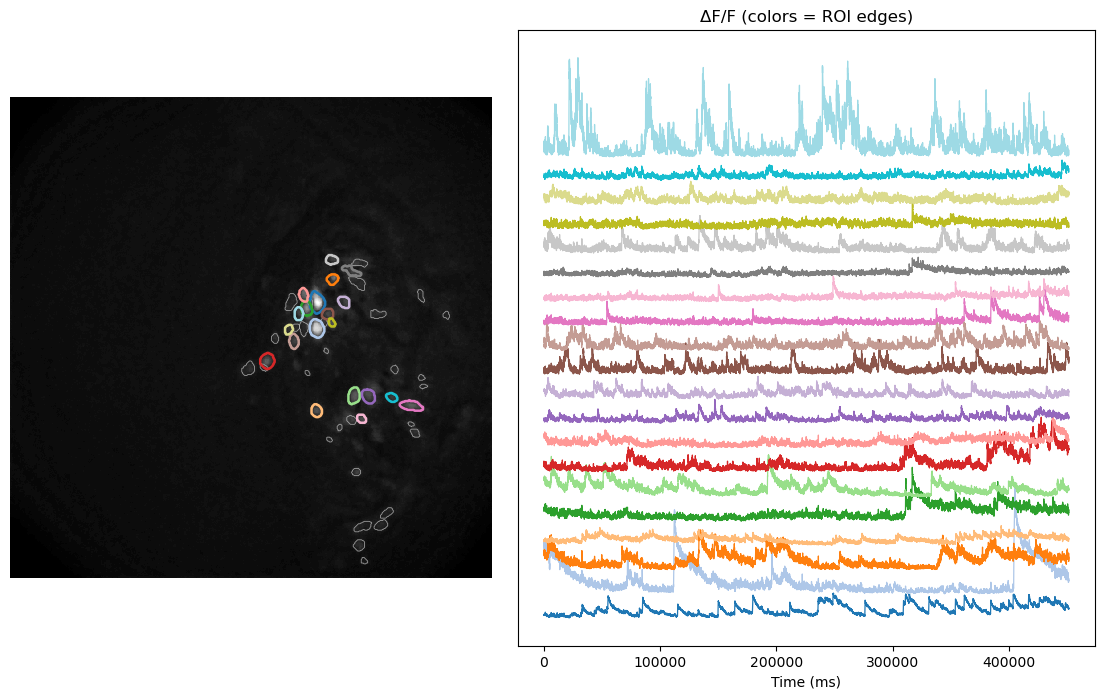

In [20]:
# selected_neurons = [27,34,10, 21,  3, 36, 11, 33, 25,  5, 32,  9, 14, 23, 35, 37,  2,  0, 17, 20,  12]
# 34, 10

selected_neurons = [10, 21,  3, 36, 11, 33, 25,  5, 32,  9, 14, 23, 35, 37,  2,  0, 17, 20, 34, 12]
# # 1) Color overlay with numbers (for iteration)
# fig1, ax1 = roi_overlay_colored(data, max_proj, selected_neurons, show_ids=True)

# # 2) Presentation-clean overlay (no numbers)
# fig2, ax2 = roi_overlay_colored(data, max_proj, selected_neurons, show_ids=False)

# # 3) Side-by-side overlay + ΔF/F with matched colors (iterating)
# fig3, (ax_img, ax_plot) = overlay_and_dff(data, max_proj, dF_F, ts, selected_neurons, show_ids=True)

# 4) Presentation version of #3 (no numbers)
fig4, _ = overlay_and_dff(data, max_proj, dF_F, ts, selected_neurons, show_ids=False)


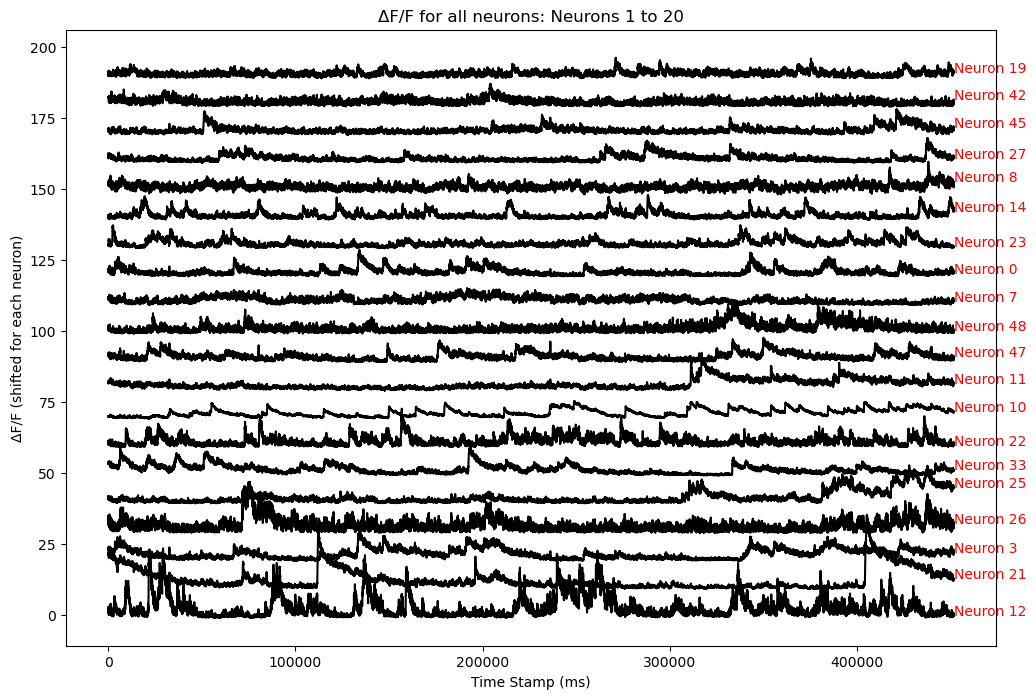

Neuron indices for plot 1:
[12 21  3 26 25 33 22 10 11 47 48  7  0 23 14  8 27 45 42 19]


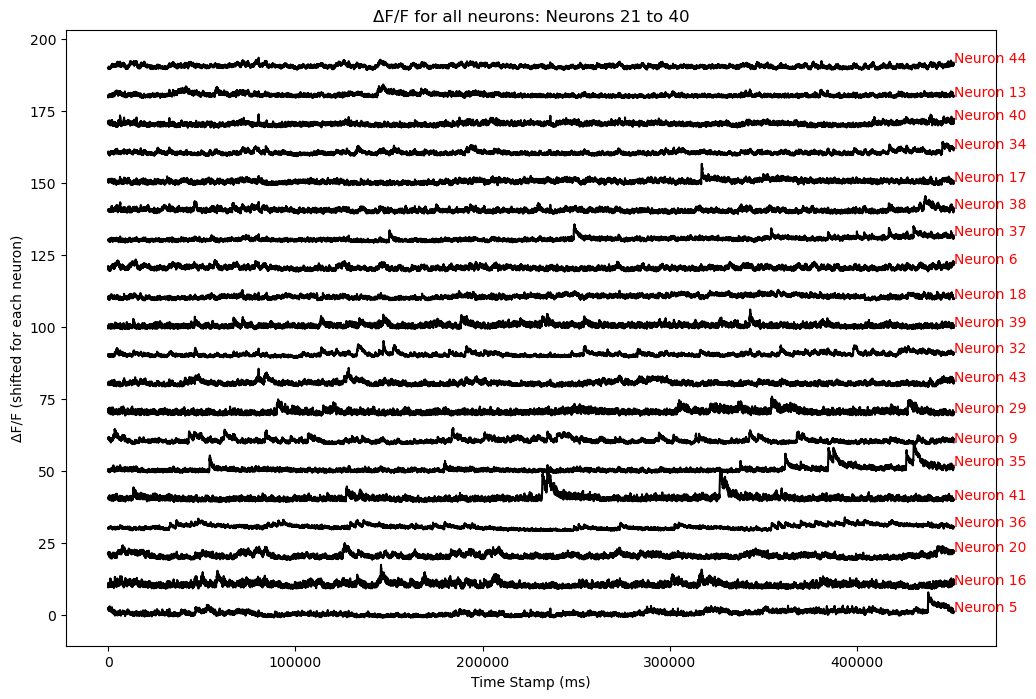

Neuron indices for plot 2:
[ 5 16 20 36 41 35  9 29 43 32 39 18  6 37 38 17 34 40 13 44]


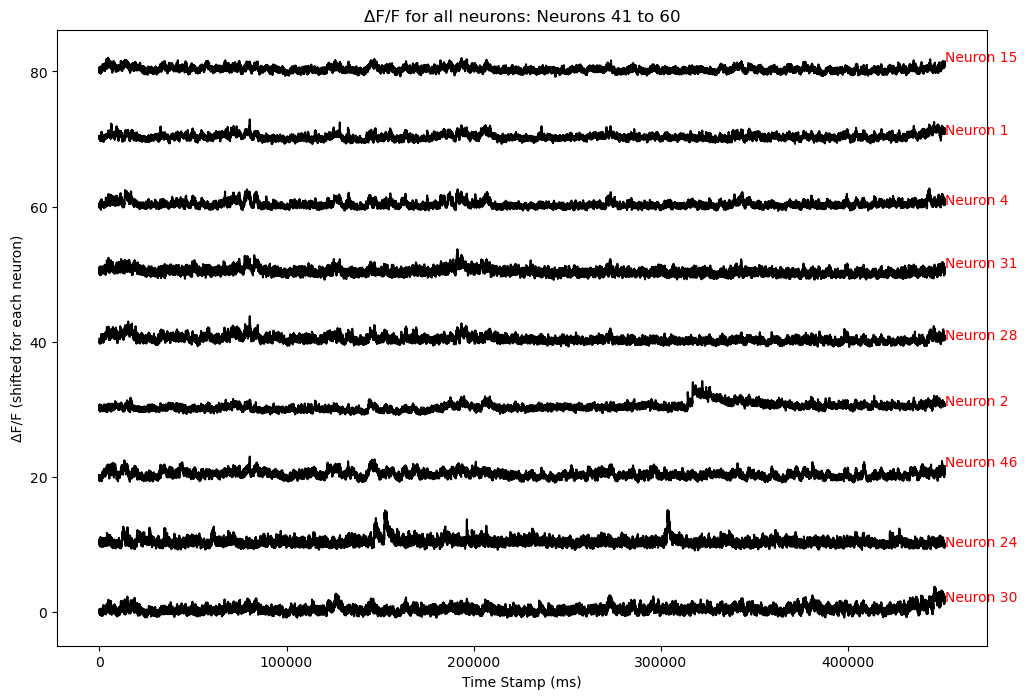

Neuron indices for plot 3:
[30 24 46  2 28 31  4  1 15]


In [13]:
plot_all_dff(dF_F, ts, title="ΔF/F for all neurons", neurons_per_plot=20)

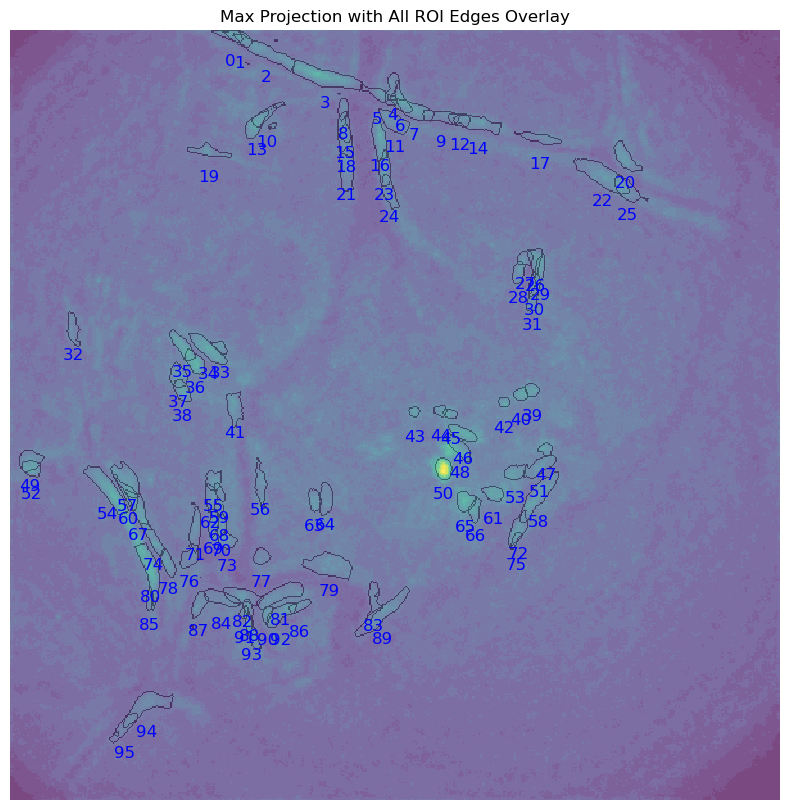

In [4]:
max_proj = data['max_proj'].values
overlay_all_roi_edges(data, max_proj)

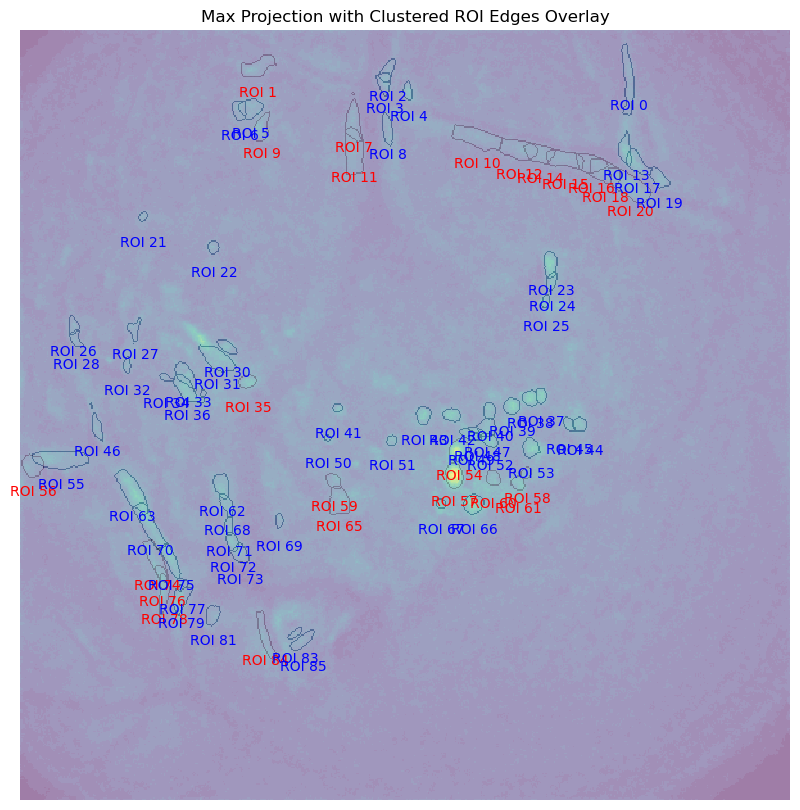

In [11]:
cluster1= ['dF_F_roi1', 'dF_F_roi7', 'dF_F_roi9', 'dF_F_roi10', 'dF_F_roi11', 'dF_F_roi12', 'dF_F_roi14', 'dF_F_roi15', 'dF_F_roi16', 'dF_F_roi18', 'dF_F_roi20', 'dF_F_roi35', 'dF_F_roi54', 'dF_F_roi56', 'dF_F_roi57', 'dF_F_roi58', 'dF_F_roi59', 'dF_F_roi60', 'dF_F_roi61', 'dF_F_roi65', 'dF_F_roi74', 'dF_F_roi76', 'dF_F_roi78', 'dF_F_roi84']
cluster2= ['dF_F_roi0', 'dF_F_roi2', 'dF_F_roi3', 'dF_F_roi4', 'dF_F_roi5', 'dF_F_roi6', 'dF_F_roi8', 'dF_F_roi13', 'dF_F_roi17', 'dF_F_roi19', 'dF_F_roi21', 'dF_F_roi22', 'dF_F_roi23', 'dF_F_roi24', 'dF_F_roi25', 'dF_F_roi26', 'dF_F_roi27', 'dF_F_roi28', 'dF_F_roi30', 'dF_F_roi31', 'dF_F_roi32', 'dF_F_roi33', 'dF_F_roi34', 'dF_F_roi36', 'dF_F_roi37', 'dF_F_roi38', 'dF_F_roi39', 'dF_F_roi40', 'dF_F_roi41', 'dF_F_roi42', 'dF_F_roi43', 'dF_F_roi44', 'dF_F_roi45', 'dF_F_roi46', 'dF_F_roi47', 'dF_F_roi48', 'dF_F_roi49', 'dF_F_roi50', 'dF_F_roi51', 'dF_F_roi52', 'dF_F_roi53', 'dF_F_roi55', 'dF_F_roi62', 'dF_F_roi63', 'dF_F_roi66', 'dF_F_roi67', 'dF_F_roi68', 'dF_F_roi69', 'dF_F_roi70', 'dF_F_roi71', 'dF_F_roi72', 'dF_F_roi73', 'dF_F_roi75', 'dF_F_roi77', 'dF_F_roi79', 'dF_F_roi81', 'dF_F_roi83', 'dF_F_roi85']

def overlay_clustered_roi_edges(data, max_proj, cluster1, cluster2):
    """
    Overlay edges of ROIs from two clusters on the max projection image in different colors.
    
    Parameters:
        data: dict
            Contains the 'A' matrix representing ROIs.
        max_proj: ndarray
            Max projection image for overlay.
        cluster1: list
            List of ROIs belonging to Cluster 1.
        cluster2: list
            List of ROIs belonging to Cluster 2.
    """
    # Convert cluster ROI names to indices
    roi_mapping = {f"dF_F_roi{i}": i for i in range(data['A'].shape[0])}
    cluster1_indices = [roi_mapping[roi] for roi in cluster1]
    cluster2_indices = [roi_mapping[roi] for roi in cluster2]
    
    # Convert sparse matrix to dense
    A_dense = data['A'].values if hasattr(data['A'], 'values') else csc_matrix(
        (data['A'].data, data['A'].indices, data['A'].indptr), shape=data['A'].shape).toarray()
    
    # Initialize overlays
    cluster1_overlay = np.zeros_like(max_proj, dtype=float)
    cluster2_overlay = np.zeros_like(max_proj, dtype=float)
    
    # Generate overlay for Cluster 1
    for roi in cluster1_indices:
        roi_mask = A_dense[roi].reshape(max_proj.shape) > 0
        roi_edge = roi_mask ^ binary_erosion(roi_mask)
        cluster1_overlay += roi_edge
    
    # Generate overlay for Cluster 2
    for roi in cluster2_indices:
        roi_mask = A_dense[roi].reshape(max_proj.shape) > 0
        roi_edge = roi_mask ^ binary_erosion(roi_mask)
        cluster2_overlay += roi_edge
    
    # Clip overlays to ensure valid values
    cluster1_overlay = np.clip(cluster1_overlay, 0, 1)
    cluster2_overlay = np.clip(cluster2_overlay, 0, 1)
    
    # Plot the max projection with overlays
    plt.figure(figsize=(10, 10))
    plt.imshow(max_proj, interpolation='nearest')
    plt.imshow(cluster1_overlay, cmap='Reds', alpha=0.3, interpolation='nearest')
    plt.imshow(cluster2_overlay, cmap='Blues', alpha=0.3, interpolation='nearest')
    
    # Optionally label centroids for both clusters
    for roi, cluster_color in zip([cluster1_indices, cluster2_indices], ['red', 'blue']):
        for idx in roi:
            roi_mask = A_dense[idx].reshape(max_proj.shape) > 0
            coords = np.argwhere(roi_mask)
            if coords.size > 0:
                centroid = coords.mean(axis=0)
                plt.text(centroid[1], centroid[0] + 20, f"ROI {idx}", color=cluster_color, fontsize=10, ha='center', va='center')
    
    plt.title('Max Projection with Clustered ROI Edges Overlay')
    plt.axis('off')
    plt.show()

overlay_clustered_roi_edges(data, max_proj, cluster1, cluster2)